# NYC Bike Data: Dataset Description & Exploratory Analysis

This notebook documents and explores every dataset used in the project and underpins the
**technical report** in `docs/technical-report/`. It covers, in order of importance:

1. **Citi Bike dataset**: the project's main data source with bike trip records (one monthly file, downloaded manually).
2. **Station metadata**: current Citi Bike stations from the Lyft GBFS feed (fetched live).
3. **Weather**: hourly NYC observations from the Open-Meteo archive (fetched live).
4. **Bike lanes**: NYC bike-route network from NYC OpenData (fetched live).

For each dataset we describe its **structure**, run **exploratory data analysis (EDA)**, and
assess **data quality**. See `src/notebooks/README.md` for how to obtain the ride data and run
this notebook.

## 0. Setup

Imports, data sources, shared constants and the utility helpers every section below reuses.

In [1]:
import io
import math
import re
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import folium
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from PIL import Image

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Where to find the manually-downloaded Citi Bike monthly CSV(s) (relative to this notebook).
DATA_DIR = Path("data")

# Data sources (mirrors src/ingestion/config.yaml and src/backend/config.yaml).
WEATHER_API_URL = "https://archive-api.open-meteo.com/v1/archive"
BIKE_ROUTES_URL = "https://data.cityofnewyork.us/api/views/mzxg-pwib/rows.csv?accessType=DOWNLOAD"
GBFS_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"
GBFS_STATUS_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_status.json"
NYC_LAT, NYC_LON = 40.7823234, -73.9654161
NYC_TZ = "America/New_York"

# Coordinate window a real NYC point must fall inside (used by the data-quality checks).
NYC_LAT_RANGE, NYC_LON_RANGE = (40.4, 41.1), (-74.3, -73.6)

# Distance-feature constants (see src/ingestion/sources/distances.py).
EARTH_RADIUS_KM = 6371
STREET_CIRCUITY_FACTOR = 1.3

### 0.1 Utilities

Two helpers are shared by the sections below. The first is the Haversine distance, computed as:

$$d = 2 r \arcsin \sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cos(\phi_2) \sin^2\left(\frac{\Delta \lambda}{2}\right)}$$

where $\phi$ is latitude, $\lambda$ is longitude, and $r$ is the Earth's radius (6371 km).
The second builds the per-column missing-value table that every data-quality section reports.

In [2]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km) scaled by the street-circuity factor, as in src/ingestion/sources/distances.py."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c * STREET_CIRCUITY_FACTOR


def missing_table(frame, cols):
    """Missing count and percentage for each of `cols`, most affected first."""
    nulls = frame[cols].isna().sum()
    return (pd.DataFrame({"missing": nulls, "pct (%)": (nulls / len(frame) * 100).round(2)})
            .sort_values("missing", ascending=False, kind="stable"))

## 1. Citi Bike Trip Data

The core dataset Citi Bike publishes one CSV per month, each row a single trip, available from
the [system data page](https://www.citibikenyc.com/system-data). Download one month and place the
extracted CSV in the `data/` folder next to this notebook (see `README.md`). The analysis shown here uses the **February 2025** file (`202502-citibike-tripdata`).

Newer files (2020+) and the legacy (pre-2020) schema use different column names. This map normalises the legacy columns to the modern schema so the rest of the notebook works regardless of which month was downloaded.

In [3]:
LEGACY_RENAME = {
    "starttime": "started_at",
    "stoptime": "ended_at",
    "start station name": "start_station_name",
    "start station id": "start_station_id",
    "end station name": "end_station_name",
    "end station id": "end_station_id",
    "start station latitude": "start_lat",
    "start station longitude": "start_lng",
    "end station latitude": "end_lat",
    "end station longitude": "end_lng",
}

def load_rides(data_dir: Path):
    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {data_dir.resolve()}. Download a Citi Bike monthly "
            "trip file, extract it, and place the CSV here. See src/notebooks/README.md."
        )
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)

    is_legacy = "rideable_type" not in df.columns
    if is_legacy:
        df = df.rename(columns=LEGACY_RENAME)
        if "usertype" in df.columns:
            df["member_casual"] = df["usertype"].map(
                {"Subscriber": "member", "Customer": "casual"}
            ).fillna(df["usertype"])
        df["rideable_type"] = pd.NA          # absent before the e-bike rollout
        if "ride_id" not in df.columns:
            df["ride_id"] = df.index.astype(str)

    # Recent months carry fractional seconds meanwhile older months do not. Use a mixed format to handle both.
    for col in ["started_at", "ended_at"]:
        try:
            df[col] = pd.to_datetime(df[col], format="ISO8601")
        except (ValueError, TypeError):
            df[col] = pd.to_datetime(df[col], format="mixed")
    return df, {"files": [f.name for f in csv_files], "is_legacy": is_legacy}

df, meta = load_rides(DATA_DIR)
print("Loaded files :", meta["files"])
print("Schema       :", "legacy (pre-2020)" if meta["is_legacy"] else "modern (2020+)")
print("Shape        :", df.shape)
df.head()

Loaded files : ['202502-citibike-tripdata_1.csv', '202502-citibike-tripdata_2.csv', '202502-citibike-tripdata_3.csv']
Schema       : modern (2020+)
Shape        : (2031257, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,CB5406D3D5F737FD,electric_bike,2025-02-02 00:19:27.351,2025-02-02 00:31:15.349,Windsor Pl & 8 Ave,3620.02,New York Ave & Hawthorne St,3504.02,40.660906,-73.983074,40.657940,-73.947350,member
1,C121FE82B33D3C0B,classic_bike,2025-02-12 14:21:54.750,2025-02-12 14:36:30.914,N 5 St & Wythe Ave,5419.04,Bushwick Ave & Stagg St,5140.06,40.718389,-73.961501,40.709897,-73.940080,member
2,3ABBEFFA37358AF5,electric_bike,2025-02-10 19:01:06.941,2025-02-10 19:10:11.898,W 82 St & Central Park W,7304.08,E 75 St & 3 Ave,6991.12,40.782750,-73.971370,40.771129,-73.957723,member
3,35C2CFDA66D8E492,electric_bike,2025-02-01 18:25:35.756,2025-02-01 18:43:23.495,Classon Ave & St Marks Ave,4074.14,Central Ave & Melrose St,4832.07,40.676513,-73.959431,40.701120,-73.930390,member
4,91524588E010013A,electric_bike,2025-02-11 08:44:16.954,2025-02-11 08:56:33.197,8 Ave & W 33 St,6450.12,Madison Ave & E 51 St,6659.09,40.751551,-73.993934,40.758630,-73.975130,member


### 1.1 Structure

We provide a brief overview of the dataset's structure, including column names, data types, and sample records, through the `pandas` library. 

In [4]:
df.info()

print("\nUnique rideable_type :", df["rideable_type"].dropna().unique().tolist())
print("Unique member_casual :", df["member_casual"].dropna().unique().tolist())

unique_stations = pd.concat([df["start_station_name"], df["end_station_name"]]).nunique()
print(f"Unique stations      : {unique_stations}")
print(f"Date range           : {df['started_at'].min()} -> {df['started_at'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 2031257 entries, 0 to 2031256
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       str           
dtypes: datetime64[us](2), float64(4), object(1), str(6)
memory usage: 201.5+ MB

Unique rideable_type : ['electric_bike', 'classic_bike']
Unique member_casual : ['member', 'casual']
Unique stations      : 2177
Date range           : 2025-01-31 09:26:50.490000 -> 2025-02-28 23:58:02.884000


### 1.2 Extracted Features

Additional per-trip features are derived to support the analysis: the **trip duration**, as
$\text{Ended At} - \text{Started At}$, and the **trip distance**, from the Haversine formula
scaled by the $1.3$ circuity factor. The hour and day type used by the temporal analysis are
taken from the end timestamp. **Station popularity** and **trip flows** are aggregations over
these trips, so they are computed in the spatial section where they are read.

In [5]:
df["ride_length_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
df["trip_distance_km"] = haversine_km(
    df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"]
)

# Hour, date and day type are taken from the END timestamp, matching the ingestion pipeline.
df["hour"] = df["ended_at"].dt.hour
df["date"] = df["ended_at"].dt.date
df["day_type"] = np.where(df["ended_at"].dt.weekday < 5, "Weekday", "Weekend")

print("Derived features:")
print(df[["ride_length_min", "trip_distance_km", "hour", "date", "day_type"]].head().to_string())

Derived features:
   ride_length_min  trip_distance_km  hour        date day_type
0        11.799967          3.940802     0  2025-02-02  Weekend
1        14.602733          2.648680    14  2025-02-12  Weekday
2         9.082617          2.247978    19  2025-02-10  Weekday
3        17.795650          4.773360    18  2025-02-01  Weekend
4        12.270717          2.299301     8  2025-02-11  Weekday


### 1.3 Temporal Patterns

Demand varies across the hours of the day and between weekdays and weekends: weekday trips peak
during standard commuting hours, whereas weekend usage shifts toward leisure-oriented patterns.

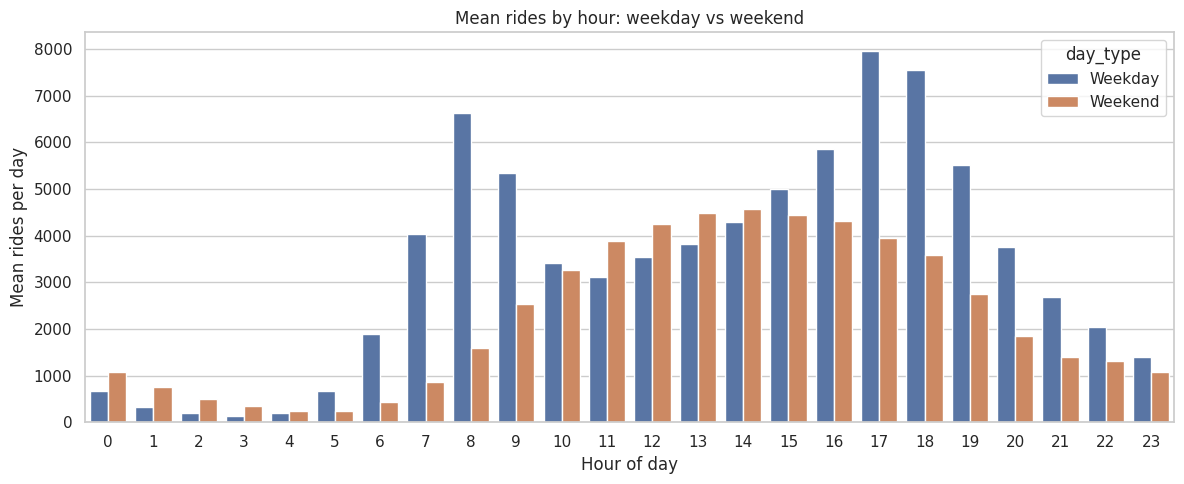

In [6]:
# Mean rides per hour, separating weekdays from weekends.
hourly = df.groupby(["date", "hour", "day_type"]).size().reset_index(name="rides")
mean_rides = hourly.groupby(["hour", "day_type"])["rides"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="hour", y="rides", hue="day_type", data=mean_rides)
plt.xlabel("Hour of day")
plt.ylabel("Mean rides per day")
plt.title("Mean rides by hour: weekday vs weekend")
plt.tight_layout()
plt.show()

### 1.4 Spatial Patterns

Station popularity and trip flows reveal that demand is concentrated around Manhattan and other
high-density areas, with some stations acting as important origins. Trip origins are aggregated
into **300 m cells** rather than drawn as a smooth heat layer: a heat layer normalises its colours
by the busiest pixel and blends overlapping stations, so its shading cannot be read off a legend,
whereas each cell here carries an exact trip count.

In [7]:
# Trip origins, aggregated into fixed cells so every colour maps to an exact trip count.
CELL_M = 300                              # side of the aggregation cell, in metres
BREAKS = [0, 250, 500, 1000, 2500, 5000]  # lower bound of each colour class
COLORS = ["#ffffb2", "#fed976", "#feb24c", "#fd8d3c", "#f03b20", "#bd0026"]

origins = (
    df.dropna(subset=["start_lat", "start_lng", "start_station_name"])
    .groupby("start_station_name")
    .agg(lat=("start_lat", "first"), lon=("start_lng", "first"), rides=("ride_id", "count"))
    .reset_index()
)

dlat = CELL_M / 111_320  # degrees of latitude per cell; longitude shrinks with the cosine
dlon = CELL_M / (111_320 * np.cos(np.radians(origins["lat"].median())))
cells = (
    origins.assign(lat0=np.floor(origins["lat"] / dlat) * dlat,
                   lon0=np.floor(origins["lon"] / dlon) * dlon)
    .groupby(["lat0", "lon0"], as_index=False)
    .agg(rides=("rides", "sum"), stations=("start_station_name", "size"))
)
print(f"Origin stations : {len(origins):,}")
print(f"Cells of {CELL_M} m   : {len(cells):,}")
print(f"Busiest cell    : {cells['rides'].max():,} trips")

# Median centre, so the few demo stations the feed places outside NYC do not pull the view.
bike_map = folium.Map(location=[origins["lat"].median(), origins["lon"].median()],
                      zoom_start=12)
for c in cells.itertuples():
    folium.Rectangle(
        bounds=[[c.lat0, c.lon0], [c.lat0 + dlat, c.lon0 + dlon]],
        weight=0, fill=True, fill_opacity=0.75,
        fill_color=COLORS[np.searchsorted(BREAKS, c.rides, side="right") - 1],
        tooltip=f"{c.rides:,} trips started ({c.stations} station(s))",
    ).add_to(bike_map)

# Legend built from the same breaks the cells are coloured with, so the two cannot drift.
swatches = "".join(
    f'<div><span style="display:inline-block;width:1.15em;height:1.15em;background:{col};'
    f'margin-right:.5em;vertical-align:-.2em"></span>'
    f'{lo:,}{f" &ndash; {hi:,}" if hi else "+"}</div>'
    for lo, hi, col in zip(BREAKS, BREAKS[1:] + [None], COLORS)
)
bike_map.get_root().html.add_child(folium.Element(
    '<div class="map-legend" style="position:fixed;bottom:2em;left:1em;z-index:9999;'
    'padding:.6em .8em;background:rgba(255,255,255,.9);border:1px solid #999;'
    'border-radius:4px;font:12px/1.5 sans-serif"><b>Trips started</b><br>'
    f'<span style="color:#555">per {CELL_M} m cell</span>{swatches}</div>'
))
bike_map

Origin stations : 2,147
Cells of 300 m   : 1,610
Busiest cell    : 12,417 trips


In [8]:
# Station-to-station flow: how many trips run between each ordered station pair.
flow = (
    df.dropna(subset=["start_station_name", "end_station_name"])
    .groupby(["start_station_name", "end_station_name"]).size()
    .reset_index(name="trips")
)
print(f"Distinct station pairs with at least one trip: {len(flow):,}")
print("\nTop 10 station-to-station flows:")
print(flow.sort_values("trips", ascending=False).head(10).to_string(index=False))

Distinct station pairs with at least one trip: 393,405

Top 10 station-to-station flows:
           start_station_name         end_station_name  trips
       Norfolk St & Broome St      Henry St & Grand St    455
          Henry St & Grand St   Norfolk St & Broome St    401
         Jackson Ave & 49 Ave  Franklin St & Dupont St    391
      Franklin St & Dupont St     Jackson Ave & 49 Ave    380
              E 77 St & 1 Ave          2 Ave & E 72 St    373
         55 Ave & Center Blvd     Vernon Blvd & 50 Ave    365
North Moore St & Greenwich St Vesey Pl & River Terrace    360
        Clinton St & Grand St      Henry St & Grand St    344
              W 41 St & 8 Ave          E 48 St & 5 Ave    343
              W 21 St & 6 Ave          9 Ave & W 22 St    332


### 1.5 Bike Type and User Type

Casual riders lean much more heavily on electric bikes than members do, and they take longer trips
on both bike types, whereas members maintain a steady, short duration regardless of the bike they
choose. The first panel shows the **bike-type mix within each user type**, the second the **median
ride length by user and bike type**.

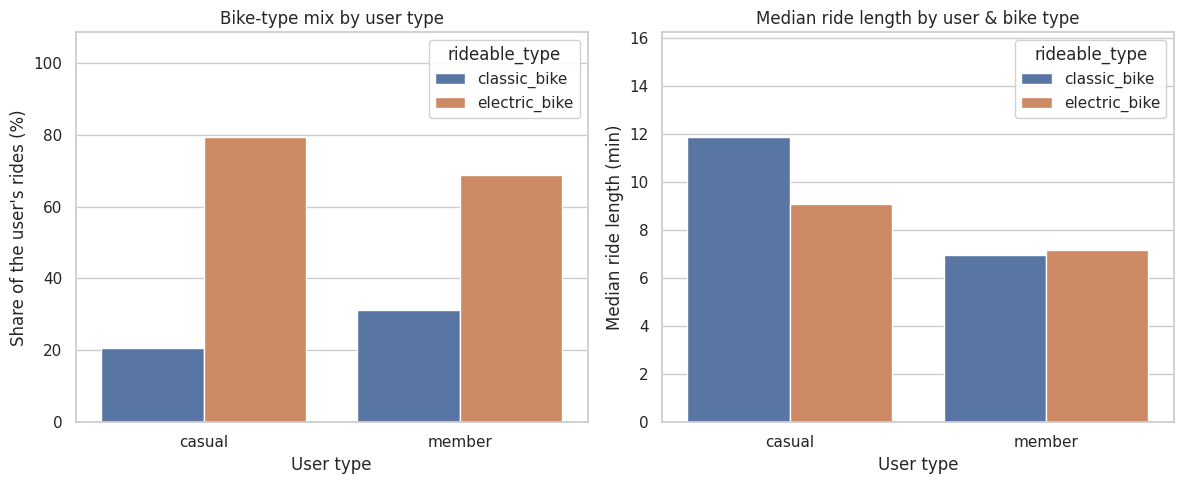

Share of rides by user type (%):
member_casual
member    90.5
casual     9.5

Share of rides by bike type (%):
rideable_type
electric_bike    69.7
classic_bike     30.3


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bike-type mix *within* each user type (share, not raw volume)
counts = df.groupby(["member_casual", "rideable_type"]).size().reset_index(name="rides")
counts["share"] = 100 * counts["rides"] / counts.groupby("member_casual")["rides"].transform("sum")
sns.barplot(data=counts, x="member_casual", y="share", hue="rideable_type", ax=axes[0])
axes[0].set(title="Bike-type mix by user type", xlabel="User type",
            ylabel="Share of the user's rides (%)")

# Median ride length by user and bike type
med = (df.groupby(["member_casual", "rideable_type"])["ride_length_min"]
         .median().reset_index())
sns.barplot(data=med, x="member_casual", y="ride_length_min", hue="rideable_type", ax=axes[1])
axes[1].set(title="Median ride length by user & bike type", xlabel="User type",
            ylabel="Median ride length (min)")

# Add headroom and pin each legend to the top-right so it never overlaps a bar.
for ax in axes:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
    ax.legend(title="rideable_type", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

print("Share of rides by user type (%):")
print((df["member_casual"].value_counts(normalize=True) * 100).round(1).to_string())
print("\nShare of rides by bike type (%):")
print((df["rideable_type"].value_counts(normalize=True) * 100).round(1).to_string())

### 1.6 Trip Duration

Most trips are relatively short, while longer rides are less frequent and often correspond to
recreational usage. Durations begin at one minute, as Citi Bike removes trips shorter than
60 seconds at the source. Every trip is kept, so the tail above 60 minutes stays visible.

Ride length (minutes) summary:
mean        10.16
median       7.30
min          1.00
max       1499.97
std         23.85


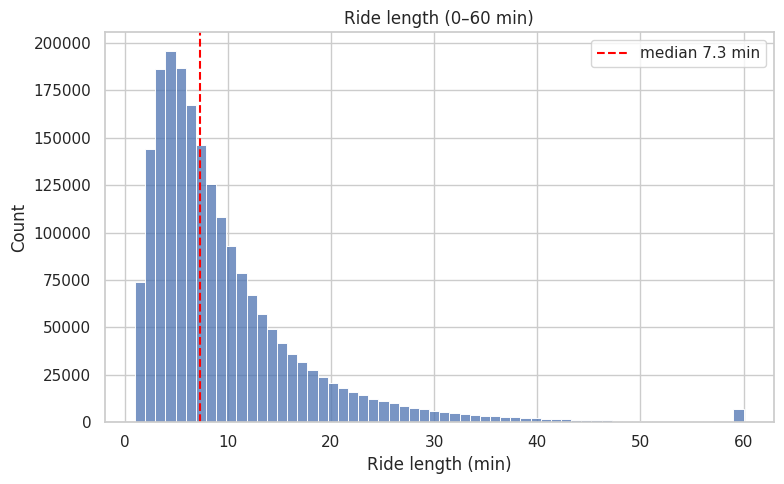

In [10]:
print("Ride length (minutes) summary:")
print(df["ride_length_min"].agg(["mean", "median", "min", "max", "std"]).round(2).to_string())

plt.figure(figsize=(8, 5))
sns.histplot(df["ride_length_min"].clip(lower=0, upper=60), bins=60)
plt.axvline(df["ride_length_min"].median(), color="red", ls="--",
            label=f"median {df['ride_length_min'].median():.1f} min")
plt.title("Ride length (0\u201360 min)")
plt.xlabel("Ride length (min)")
plt.legend()
plt.tight_layout()
plt.show()

### 1.7 Trip Distance

This is the **straight-line** distance between the start and end stations, scaled by a 1.3
circuity factor to approximate the real on-street path. No trips are excluded: **round trips**
that begin and end at the same station appear as the **0 km** bar (the straight-line metric
cannot capture their real path), and the long-distance tail is folded into the final bin
so these anomalies stay visible. Both must be considered when interpreting the distribution or
computing distance-based statistics (e.g., average distance per trip, average speed).

Trip distance (km) summary:
mean          2.30
median        1.73
min           0.00
max       11259.08
std          11.35


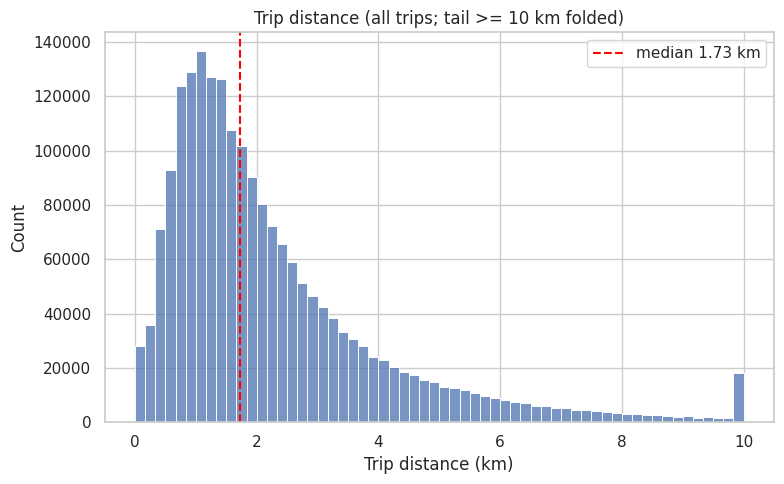

In [11]:
print("Trip distance (km) summary:")
print(df["trip_distance_km"].agg(["mean", "median", "min", "max", "std"]).round(2).to_string())

cap = 10  # km; distances above this collapse into the last bin
plt.figure(figsize=(8, 5))
sns.histplot(df["trip_distance_km"].clip(upper=cap), bins=60)
plt.axvline(df["trip_distance_km"].median(), color="red", ls="--",
            label=f"median {df['trip_distance_km'].median():.2f} km")
plt.xlabel("Trip distance (km)")
plt.title("Trip distance (all trips; tail >= 10 km folded)")
plt.legend()
plt.tight_layout()
plt.show()

### 1.8 Data Quality

To prevent misleading visual representations and maintain data integrity, we identified several
data quality issues in the raw Citi Bike dataset prior to plotting.

#### Different Structure

Citi Bike's trip-file schema changed around **2020**. Files from **2013-2019** (and the Jersey
City `JC-*` files) use a **legacy** layout: space-separated column names, a `bikeid`, a `usertype`
of `Subscriber`/`Customer`, and rider demographics (`gender`, `birth year`); they carry no
`ride_id` and no `rideable_type` (electric bikes did not exist yet). From **2020** onward the
files use the **modern** schema analysed above.

In [12]:
# The modern layout (2020+, loaded above) against the legacy pre-2020 one LEGACY_RENAME maps onto it.
MODERN = ["ride_id", "rideable_type", "started_at", "ended_at",
          "start_station_name", "start_station_id", "end_station_name", "end_station_id",
          "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]
assert all(c in df.columns for c in MODERN)  # these are the loaded modern file's raw columns

modern_to_legacy = {v: k for k, v in LEGACY_RENAME.items()}
modern_to_legacy["member_casual"] = "usertype"
notes = {
    "ride_id": "added - unique trip id",
    "rideable_type": "added - classic vs electric (e-bikes)",
    "member_casual": "renamed + recoded (Subscriber->member, Customer->casual)",
}
rows = [{"Modern (2020+)": c,
         "Legacy (2013-2019)": modern_to_legacy.get(c, "-"),
         "Change": notes.get(c, "renamed")}
        for c in MODERN]
for leg, note in [("tripduration", "dropped - derivable from timestamps"),
                  ("bikeid", "dropped - physical bike id"),
                  ("birth year", "dropped - rider demographic"),
                  ("gender", "dropped - rider demographic")]:
    rows.append({"Modern (2020+)": "-", "Legacy (2013-2019)": leg, "Change": note})

print(f"Loaded month uses the {'LEGACY' if meta['is_legacy'] else 'MODERN'} schema.")
pd.DataFrame(rows)

Loaded month uses the MODERN schema.


,Modern (2020+),Legacy (2013-2019),Change
0,ride_id,-,added - unique trip id
1,rideable_type,-,added - classic vs electric (e-bikes)
2,started_at,starttime,renamed
3,ended_at,stoptime,renamed
4,start_station_name,start station name,renamed
5,start_station_id,start station id,renamed
6,end_station_name,end station name,renamed
7,end_station_id,end station id,renamed
8,start_lat,start station latitude,renamed
9,start_lng,start station longitude,renamed


#### Missing Values

A small share of trips have missing values, and they are confined to the **station** columns.
The **end-of-trip** fields (`end_station_name`, `end_station_id`, `end_lat`, `end_lng`) are the most
affected probably due to trips ending away from a station. The non-station columns (`ride_id`, `rideable_type`, `started_at`,
`ended_at`, `member_casual`) have no missing values. The table below reports the missing count and
percentage for every raw column.

In [13]:
raw_cols = ["ride_id", "rideable_type", "started_at", "ended_at",
            "start_station_name", "start_station_id", "end_station_name", "end_station_id",
            "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]
print(f"{len(df):,} trips loaded; missing values per column:")
missing_table(df, raw_cols)

2,031,257 trips loaded; missing values per column:


,missing,pct (%)
end_station_id,4777,0.24
end_lat,4756,0.23
end_lng,4756,0.23
end_station_name,4454,0.22
start_station_name,673,0.03
start_station_id,673,0.03
start_lat,673,0.03
start_lng,673,0.03
ride_id,0,0.00
rideable_type,0,0.00


#### Trip Outliers

A handful of trips are clearly not ordinary rides. Some are **too long**
which points to a bike that was never returned rather than a continuous ride. Others cover **zero
straight-line distance** because they start and end at the same station (round trips the
point-to-point distance cannot capture). A few are **impossibly far** caused by
broken station coordinates (an endpoint at latitude/longitude 0, 0). The table below shows
examples of each.

In [14]:
cols = ["started_at", "ride_length_min", "trip_distance_km",
        "start_station_name", "end_station_name", "member_casual"]
too_long = (df[(df["trip_distance_km"] > 0) & df["end_station_name"].notna()]
            .nlargest(3, "ride_length_min")[cols].assign(issue="too long"))
zero_dist = (df[df["trip_distance_km"] == 0]
             .nlargest(3, "ride_length_min")[cols].assign(issue="zero distance (round trip)"))
too_far = (df[df["trip_distance_km"] > 4000]
           .nlargest(2, "trip_distance_km")[cols].assign(issue="too far (bad coordinates)"))
print(f"trips over 24 h           : {int((df['ride_length_min'] > 24 * 60).sum()):,}")
print(f"zero-distance round trips : {int((df['trip_distance_km'] == 0).sum()):,}")
print(f"trips over 4000 km        : {int((df['trip_distance_km'] > 4000).sum()):,}")
pd.concat([too_long, zero_dist, too_far]).round({"ride_length_min": 0, "trip_distance_km": 2})

trips over 24 h           : 315
zero-distance round trips : 27,422
trips over 4000 km        : 2


,started_at,ride_length_min,trip_distance_km,start_station_name,end_station_name,member_casual,issue
1114758,2025-02-19 15:28:47.062,1491.0,2.42,19 St & 8 Ave,Parade Pl & Crooke Ave,casual,too long
1014588,2025-02-25 21:21:47.629,1486.0,7.21,Prospect Pl & Vanderbilt Ave,Nassau Ave & Newell St,member,too long
1948106,2025-02-19 11:02:16.038,1483.0,1.37,Bedford Ave & Nassau Ave,N 5 St & Northside Piers,casual,too long
1678060,2025-02-25 11:23:48.341,1489.0,0.00,Rutland Rd & Brooklyn Ave,Rutland Rd & Brooklyn Ave,member,zero distance (round trip)
473041,2025-02-10 09:22:12.040,1439.0,0.00,Carlton Ave & Dean St,Carlton Ave & Dean St,member,zero distance (round trip)
1765013,2025-02-25 12:14:31.648,1411.0,0.00,Lispenard St & Broadway,Lispenard St & Broadway,member,zero distance (round trip)
250027,2025-02-12 11:32:44.680,13.0,11259.08,Morgan Bike Mechanics,Bronx WH station,member,too far (bad coordinates)
1969442,2025-02-22 13:03:17.335,14.0,11259.08,Morgan Bike Mechanics,Bronx WH station,member,too far (bad coordinates)


## 2. Station Metadata (GBFS)

Current station information and live availability from the Lyft GBFS feed (the same feed the
backend uses). Two endpoints are merged based on `station_id`: `station_information` (static: name, location, capacity)
and `station_status` (live: bikes/docks available, operational flags).

In [15]:
info = requests.get(GBFS_INFO_URL, timeout=(5, 30)).json()["data"]["stations"]
status = requests.get(GBFS_STATUS_URL, timeout=(5, 30)).json()["data"]["stations"]
status_map = {s["station_id"]: s for s in status}

rows = []
for s in info:
    st = status_map.get(s["station_id"], {})
    counts = {v.get("vehicle_type_id"): v.get("count", 0)
              for v in st.get("vehicle_types_available", [])}
    rows.append({
        "station_id": s["station_id"],
        "short_name": s.get("short_name"),
        "name": s.get("name"),
        "lat": s.get("lat"),
        "lon": s.get("lon"),
        "capacity": s.get("capacity"),
        "num_bikes_available": st.get("num_bikes_available"),
        "num_classic": counts.get("1"),
        "num_ebikes": counts.get("2"),
        "num_ebikes_reported": st.get("num_ebikes_available"),
        "num_docks_available": st.get("num_docks_available"),
        "num_bikes_disabled": st.get("num_bikes_disabled"),
        "num_docks_disabled": st.get("num_docks_disabled"),
        "is_installed": st.get("is_installed"),
        "is_renting": st.get("is_renting"),
        "is_returning": st.get("is_returning"),
    })
stations = pd.DataFrame(rows)
stations["active"] = (
    (stations["is_installed"] == 1) & (stations["is_renting"] == 1) & (stations["is_returning"] == 1)
)
print(f"Stations in feed: {len(stations)}  (active: {stations['active'].sum()})")

# The feed lists not-installed stations first, so a plain head() would show only those.
preview = pd.concat([stations[stations["active"]].head(3),
                     stations[~stations["active"]].head(2)])
preview

Stations in feed: 2462  (active: 2362)


,station_id,short_name,name,lat,lon,capacity,num_bikes_available,num_classic,num_ebikes,num_ebikes_reported,num_docks_available,num_bikes_disabled,num_docks_disabled,is_installed,is_renting,is_returning,active
20,2121032386733337206,3056.07,37 St & 13 Ave,40.641660,-73.985050,16,15,5,10,10,0,1,0,1,1,1,True
21,1862788202397235246,8741.01,Bailey Ave & W 229 St,40.874490,-73.904670,21,13,5,8,8,4,4,0,1,1,1,True
22,1828965347681089818,3157.08,Turner Pl & Coney Island Ave,40.645210,-73.970730,20,17,17,0,0,2,1,0,1,1,1,True
0,b713367c-3572-4225-b74a-9319ab537838,8539.02,Sedgwick Ave & Hall of Fame Terrace,40.859532,-73.913303,19,0,0,0,0,0,0,0,0,0,0,False
1,66dd1f44-0aca-11e7-82f6-3863bb44ef7c,5785.05,Greenpoint Ave & Manhattan Ave,40.730260,-73.953940,27,0,0,0,0,0,0,0,0,0,0,False


### 2.1 Structure

We provide a brief overview of the merged table's structure, including column names, data types, and sample records, through the `pandas` library.

Two **extracted features** are derived on top of the raw feed fields. `active` combines the three operational flags (`is_installed`, `is_renting`, `is_returning`) into a single boolean, used to filter unavailable stations out of live views. `num_classic` and `num_ebikes` split the bikes at a station by vehicle type: the feed reports availability as a list of `(vehicle_type_id, count)` pairs, so it is indexed by type id (`"1"` classic, `"2"` electric), and a type absent from that list leaves no count.

In [16]:
stations.info()

# `active` is the AND of all three flags, which only matters if they can disagree - so check.
combos = (stations.groupby(["is_installed", "is_renting", "is_returning"])
          .size().reset_index(name="stations"))
combos["all agree"] = combos[["is_installed", "is_renting", "is_returning"]].nunique(axis=1) == 1
print("\nObserved combinations of the operational flags:")
print(combos.to_string(index=False))
print(f"stations installed but neither renting nor returning: "
      f"{int(combos.loc[~combos['all agree'], 'stations'].sum())}")

print("\nExtracted features (active and inactive stations):")
print(preview[["short_name", "num_bikes_available", "num_classic", "num_ebikes",
               "is_installed", "is_renting", "is_returning", "active"]])

<class 'pandas.DataFrame'>
RangeIndex: 2462 entries, 0 to 2461
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_id           2462 non-null   str    
 1   short_name           2462 non-null   str    
 2   name                 2462 non-null   str    
 3   lat                  2462 non-null   float64
 4   lon                  2462 non-null   float64
 5   capacity             2462 non-null   int64  
 6   num_bikes_available  2462 non-null   int64  
 7   num_classic          2462 non-null   int64  
 8   num_ebikes           2462 non-null   int64  
 9   num_ebikes_reported  2462 non-null   int64  
 10  num_docks_available  2462 non-null   int64  
 11  num_bikes_disabled   2462 non-null   int64  
 12  num_docks_disabled   2462 non-null   int64  
 13  is_installed         2462 non-null   int64  
 14  is_renting           2462 non-null   int64  
 15  is_returning         2462 non-null   int64  
 16 

### 2.2 Station Capacity

We look at how the network is provisioned, through the **distribution of station capacity**: how many docks each station has, and how many stations share a given size.

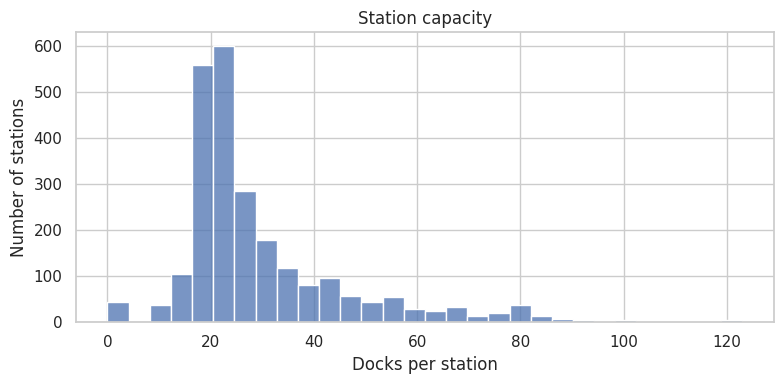

Stations                  : 2462
Median docks per station  : 23
Stations with capacity 0  : 42


In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(stations["capacity"].dropna(), bins=30)
plt.title("Station capacity")
plt.xlabel("Docks per station")
plt.ylabel("Number of stations")
plt.tight_layout()
plt.show()

print(f"Stations                  : {len(stations)}")
print(f"Median docks per station  : {stations['capacity'].median():.0f}")
print(f"Stations with capacity 0  : {int((stations['capacity'] == 0).sum())}")

### 2.3 Live Availability

We now turn to the current state of the network. The left panel sizes the two groups we are about to compare, in stations and in docks, so the breakdowns beside it are read against how much of the network each group actually is. The right panel decomposes the network's **entire capacity**, so every dock the feed knows about is counted exactly once, in one of six states: holding a rentable **classic bike** or **e-bike**, **free** to receive one, holding a bike that is **out of service**, being a **dock** that is itself out of service, or **unreported**, meaning capacity that no counter accounts for. The same breakdown is repeated for active and inactive stations, whose composition turns out to be entirely different.

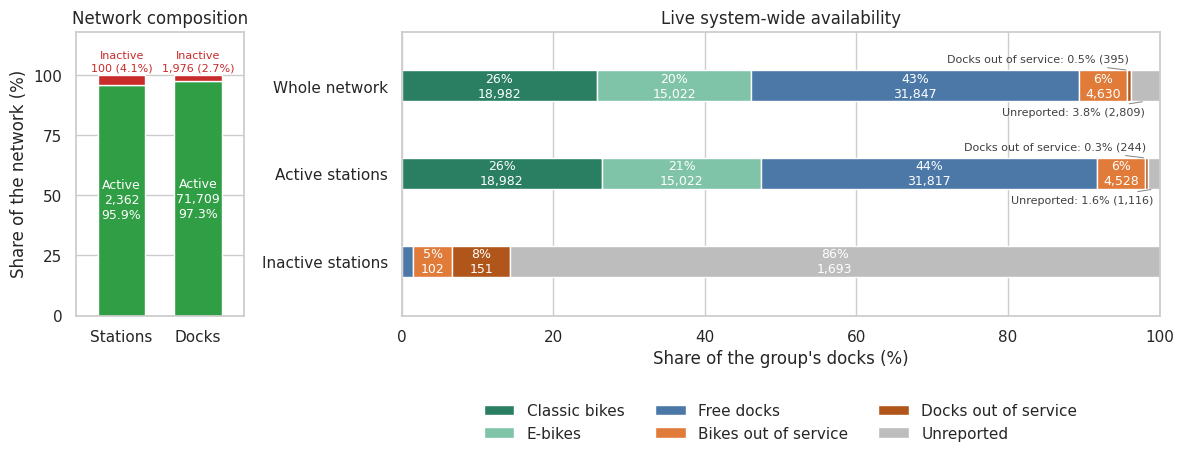

                   Stations  Classic bikes  E-bikes  Free docks  Bikes out of service  Docks out of service  Unreported  Total docks
Whole network          2462          18982    15022       31847                  4630                   395        2809        73685
Active stations        2362          18982    15022       31817                  4528                   244        1116        71709
Inactive stations       100              0        0          30                   102                   151        1693         1976

Inactive stations              : 100 of 2,462 (4.1%), holding 1,976 docks (2.7% of capacity)
E-bikes among available bikes  : 44% of 34,030
Unreported docks               : 2,809 network-wide, of which 1,693 at inactive stations
Bikes left at inactive stations: 0 rentable, 102 out of service


In [18]:
# Live snapshot: these totals change on every run.
def dock_breakdown(d):
    b = pd.Series({
        "Classic bikes": d["num_classic"].sum(),
        "E-bikes": d["num_ebikes"].sum(),
        "Free docks": d["num_docks_available"].sum(),
        "Bikes out of service": d["num_bikes_disabled"].sum(),
        "Docks out of service": d["num_docks_disabled"].sum(),
    })
    b["Unreported"] = d["capacity"].sum() - b.sum()  # capacity no counter accounts for
    return b

groups = {
    "Whole network": stations,
    "Active stations": stations[stations["active"]],
    "Inactive stations": stations[~stations["active"]],
}
parts = pd.DataFrame({k: dock_breakdown(d) for k, d in groups.items()}).T
share = 100 * parts.div(parts.sum(axis=1), axis=0)

network_docks = parts.loc["Whole network"].sum()
# Out-of-service docks are always called out; any other thin segment only if it is a real number of docks.
ALWAYS_LABEL = ["Bikes out of service", "Docks out of service"]
colors = dict(zip(share.columns,
                  ["#2a7f62", "#7fc4a8", "#4c78a8", "#e07b39", "#b0561a", "#bdbdbd"]))
STEP = 1.7  # vertical spacing between bars, leaving room for the call-outs around each
fig, (ax_mix, ax) = plt.subplots(1, 2, figsize=(12, 5),
                                 gridspec_kw={"width_ratios": [1, 4.5]})

# How much of the network each group is, since the shares beside it are computed within a group.
mix = pd.DataFrame({
    "Stations": [int(stations["active"].sum()), int((~stations["active"]).sum())],
    "Docks": [parts.loc["Active stations"].sum(), parts.loc["Inactive stations"].sum()],
}, index=["Active", "Inactive"])
mix_share = 100 * mix / mix.sum()
for x, group in enumerate(mix.columns):
    bottom = 0.0
    for state, face in [("Active", "#2f9e44"), ("Inactive", "#c92a2a")]:
        s, n = mix_share.loc[state, group], mix.loc[state, group]
        ax_mix.bar(x, s, bottom=bottom, color=face, width=0.62)
        if s >= 12:  # wide enough to hold the value inside the segment
            ax_mix.text(x, bottom + s / 2, f"{state}\n{int(n):,}\n{s:.1f}%",
                        ha="center", va="center", fontsize=9, color="white")
        else:        # too thin to write in: call it out above the bar, in its own colour
            ax_mix.text(x, 101, f"{state}\n{int(n):,} ({s:.1f}%)", ha="center",
                        va="bottom", fontsize=8, color=face, linespacing=1.3)
        bottom += s
ax_mix.set_xticks(range(len(mix.columns)))
ax_mix.set_xticklabels(mix.columns)
ax_mix.set(ylim=(0, 118), yticks=range(0, 101, 25), xlim=(-0.6, len(mix.columns) - 0.4),
           ylabel="Share of the network (%)", title="Network composition")
ax_mix.grid(axis="x", visible=False)

for i, g in [(n * STEP, g) for n, g in enumerate(share.index)]:
    left, thin = 0.0, 0
    for col in share.columns:
        s, n = share.loc[g, col], parts.loc[g, col]
        ax.barh(i, s, left=left, color=colors[col], height=0.6,
                label=col if i == 0 else None)
        if s >= 4:   # wide enough to hold the value inside the segment
            ax.text(left + s / 2, i, f"{s:.0f}%\n{int(n):,}", ha="center", va="center",
                    fontsize=9, color="white")
        elif n > 0 and (col in ALWAYS_LABEL or n > 0.0025 * network_docks):
            x = left + s / 2
            up = thin % 2 == 0  # alternate above / below, then step further out
            d = 0.34 * (thin // 2)  # wide enough that a leader never crosses a nearer label
            ax.annotate(f"{col}: {s:.1f}% ({int(n):,})",
                        xy=(x, i - 0.3 - d if up else i + 0.3 + d),
                        xytext=(x, i - 0.42 - d if up else i + 0.42 + d),
                        ha="right" if x > 80 else "left" if x < 20 else "center",
                        va="bottom" if up else "top", fontsize=8, color="0.25",
                        clip_on=False, arrowprops=dict(arrowstyle="-", lw=0.7, color="0.5"))
            thin += 1
        left += s

ax.set_yticks([n * STEP for n in range(len(share))])
ax.set_yticklabels(share.index)
ax.set(xlim=(0, 100), ylim=((len(share) - 1) * STEP + 1.05, -1.05),
       xlabel="Share of the group's docks (%)", ylabel="",
       title="Live system-wide availability")
ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.26), frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

summary = parts.assign(**{"Total docks": parts.sum(axis=1)})
summary.insert(0, "Stations", [len(d) for d in groups.values()])
print(summary.astype(int).to_string())

n_inactive = len(groups["Inactive stations"])
inactive_docks = int(parts.loc["Inactive stations"].sum())
print(f"\nInactive stations              : {n_inactive:,} of {len(stations):,} "
      f"({100 * n_inactive / len(stations):.1f}%), holding {inactive_docks:,} docks "
      f"({100 * inactive_docks / parts.loc['Whole network'].sum():.1f}% of capacity)")

bikes = stations["num_bikes_available"].sum()
print(f"E-bikes among available bikes  : "
      f"{100 * stations['num_ebikes'].sum() / bikes:.0f}% of {int(bikes):,}")
print(f"Unreported docks               : {int(parts.loc['Whole network', 'Unreported']):,} "
      f"network-wide, of which {int(parts.loc['Inactive stations', 'Unreported']):,} "
      f"at inactive stations")
print(f"Bikes left at inactive stations: "
      f"{int(parts.loc['Inactive stations', ['Classic bikes', 'E-bikes']].sum()):,} rentable, "
      f"{int(parts.loc['Inactive stations', 'Bikes out of service']):,} out of service")

### 2.4 Data Quality

To maintain data integrity and prevent visual distortion, our initial validation focused on three
core quality issues: unreported capacity, feed self-consistency, and identifier alignment.

#### Unreported Capacity

The grey slice in section 2.3 is the share of the network's docks that **no live counter accounts for**, and it is the largest quality issue in this dataset.
The plot below resolves the gap per station, in order to better understand its distribution.

Unreported docks (capacity - counters) : 2,894
  at inactive stations : 1,694 over 47 stations
  at active stations   : 1,200 over 760 stations (median 1, max 18 docks)
  counters > capacity  : 111 docks over 99 stations

Stations with capacity > 0 : 2,420
  reconcile exactly       : 1,514 (62.6%)


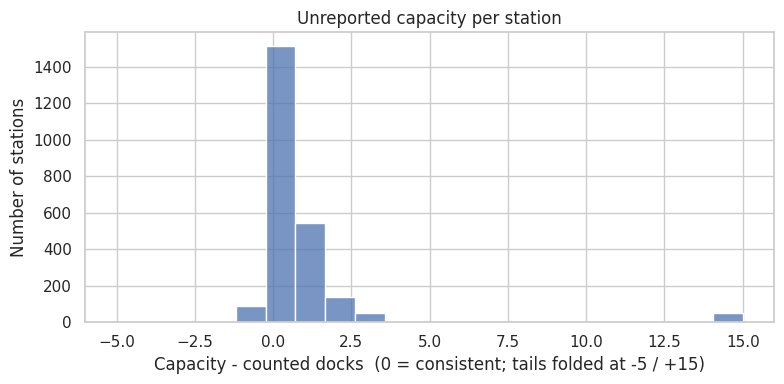

In [19]:
# Bikes available + free docks + bikes and docks out of service should equal capacity; the rest is unreported.
counted = (stations["num_bikes_available"] + stations["num_docks_available"]
           + stations["num_bikes_disabled"] + stations["num_docks_disabled"])
unreported = stations["capacity"] - counted  # > 0 docks nobody reports, < 0 counters above capacity
act, inact = stations["active"], ~stations["active"]
short = unreported > 0
sized = stations["capacity"] > 0

print(f"Unreported docks (capacity - counters) : {int(unreported[short].sum()):,}")
print(f"  at inactive stations : {int(unreported[inact & short].sum()):,} "
      f"over {int((inact & short).sum())} stations")
print(f"  at active stations   : {int(unreported[act & short].sum()):,} "
      f"over {int((act & short).sum())} stations "
      f"(median {unreported[act & short].median():.0f}, max {int(unreported[act & short].max())} docks)")
print(f"  counters > capacity  : {int(-unreported[unreported < 0].sum()):,} docks "
      f"over {int((unreported < 0).sum())} stations")
print(f"\nStations with capacity > 0 : {int(sized.sum()):,}")
print(f"  reconcile exactly       : {int((unreported[sized] == 0).sum()):,} "
      f"({100 * (unreported[sized] == 0).mean():.1f}%)")

# Per-station distribution, over the stations that declare any dock at all.
plt.figure(figsize=(8, 4))
sns.histplot(unreported[sized].clip(lower=-5, upper=15), bins=21)
plt.title("Unreported capacity per station")
plt.xlabel("Capacity - counted docks  (0 = consistent; tails folded at -5 / +15)")
plt.ylabel("Number of stations")
plt.tight_layout()
plt.show()

#### Identifier Consistency

The feed names a station **twice**, and the two identifiers are not interchangeable: `station_id` is internal to GBFS, while `short_name` is the public code of the station. Which of the two the trip files carry decides whether the live metadata can be joined to the ride history at all, so the choice is **verified below rather than assumed**.

In [20]:
# Which identifier joins the two datasets? The trips carry only one of the feed's two.
trip_ids = pd.concat([df["start_station_id"], df["end_station_id"]]).dropna().astype(str)
distinct = set(trip_ids.unique())
short_names = set(stations["short_name"].astype(str))
gbfs_ids = set(stations["station_id"].astype(str))

print(f"Distinct station ids in the trips : {len(distinct):,}")
print(f"  matching short_name : {len(distinct & short_names):,} "
      f"({100 * len(distinct & short_names) / len(distinct):.1f}%)")
print(f"  matching station_id : {len(distinct & gbfs_ids):,}")

# station_id is not even uniform in shape, which is part of why it is unusable as a public key.
is_uuid = stations["station_id"].str.fullmatch(r"[0-9a-f]{8}-[0-9a-f]{4}-.*")
print(f"\nstation_id shaped as a UUID : {int(is_uuid.sum()):,} / {len(stations):,} "
      f"(the rest are numeric strings)")

# What the unmatched trip ids are made of.
unmatched = distinct - short_names
truncated = {i for i in unmatched if re.fullmatch(r"\d+\.\d", i) and f"{i}0" in short_names}
non_station = {i for i in unmatched if not re.fullmatch(r"[\d.]+", i)}
print(f"\nTrip ids absent from the feed : {len(unmatched):,}")
print(f"  truncated decimals, recovered by padding : {len(truncated)}")
print(f"  depots, system and demo entries          : {len(non_station)} "
      f"{sorted(non_station)[:4]}")
print(f"  retired stations                         : "
      f"{len(unmatched) - len(truncated) - len(non_station)}")

legs = int(trip_ids.isin(truncated).sum())
print(f"\nStation legs lost to the truncated ids : {legs:,} "
      f"({100 * legs / len(trip_ids):.2f}% of {len(trip_ids):,})")

# The station name cannot serve as a key either.
dup_names = stations["name"].value_counts()
dup_names = dup_names[dup_names > 1]
print(f"Names shared by more than one station  : {len(dup_names)} "
      f"{list(dup_names.index)}")

Distinct station ids in the trips : 2,272
  matching short_name : 2,131 (93.8%)
  matching station_id : 0

station_id shaped as a UUID : 1,817 / 2,462 (the rest are numeric strings)

Trip ids absent from the feed : 141
  truncated decimals, recovered by padding : 90
  depots, system and demo entries          : 10 ['190 Morgan', '6569.09_', 'JC104', 'LA Metro Demo 1']
  retired stations                         : 41

Station legs lost to the truncated ids : 27,124 (0.67% of 4,057,064)
Names shared by more than one station  : 1 ['Clinton St & Grand St']


#### Missing Values

The table below is the proof that no field we consume is missing. Nulls alone would be weak evidence, since a missing value can hide as a sentinel, so every column is also checked for values that are present but cannot be real: a coordinate at the zero island or outside New York, a blank identifier, a negative count.

In [21]:
def suspect(col):
    """Values that are present but cannot be real."""
    s = stations[col]
    if col in ("lat", "lon"):
        lo, hi = NYC_LAT_RANGE if col == "lat" else NYC_LON_RANGE
        return int(((s == 0) | (s < lo) | (s > hi)).sum())   # zero island / outside NYC
    if s.dtype == bool:
        return 0
    if s.dtype.kind in "if":
        return int((s < 0).sum())                            # counts cannot be negative
    return int((s.astype(str).str.strip() == "").sum())      # blank text

completeness = missing_table(stations, stations.columns.tolist())
completeness.insert(0, "dtype", stations.dtypes.astype(str))
completeness["suspect values"] = [suspect(c) for c in completeness.index]
print(f"{len(stations):,} stations; per-column completeness:")
completeness

2,462 stations; per-column completeness:


,dtype,missing,pct (%),suspect values
station_id,str,0,0.0,0
short_name,str,0,0.0,0
name,str,0,0.0,0
lat,float64,0,0.0,0
lon,float64,0,0.0,0
capacity,int64,0,0.0,0
num_bikes_available,int64,0,0.0,0
num_classic,int64,0,0.0,0
num_ebikes,int64,0,0.0,0
num_ebikes_reported,int64,0,0.0,0


## 3. Weather Data

Hourly NYC weather from the [Open-Meteo archive API](https://open-meteo.com/), used to relate
ridership to weather.

In [22]:
ride_year = df["ended_at"].min().year
start_date = date(ride_year, 1, 1)
end_date = min(date(ride_year, 12, 31), date.today() - timedelta(days=1))

# Ask for UTC and localise here rather than passing timezone=America/New_York
resp = requests.get(
    WEATHER_API_URL,
    params={
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "start_date": (start_date - timedelta(days=1)).isoformat(),
        "end_date": (end_date + timedelta(days=1)).isoformat(),
        "hourly": "temperature_2m,precipitation,weather_code,wind_speed_10m",
        "timezone": "UTC",
        "wind_speed_unit": "kmh",
    },
    timeout=(5, 120),
)
resp.raise_for_status()

weather = pd.DataFrame(resp.json()["hourly"])
weather["datetime"] = (pd.to_datetime(weather["time"], utc=True)
                       .dt.tz_convert(NYC_TZ).dt.tz_localize(None))
weather = (weather[weather["datetime"].dt.date.between(start_date, end_date)]
           .drop(columns="time").reset_index(drop=True))
print(f"Fetched {len(weather):,} hourly rows: {start_date} -> {end_date}")
weather.head()

Fetched 8,760 hourly rows: 2025-01-01 -> 2025-12-31


,temperature_2m,precipitation,weather_code,wind_speed_10m,datetime
0,8.3,0.9,53,14.9,2025-01-01 00:00:00
1,8.7,0.0,3,7.8,2025-01-01 01:00:00
2,8.9,0.0,3,8.8,2025-01-01 02:00:00
3,8.9,0.0,3,8.8,2025-01-01 03:00:00
4,8.4,0.0,3,10.0,2025-01-01 04:00:00


### 3.1 Structure and Summary

Weather data are queried via the Open-Meteo JSON API by specifying coordinates, a date range, and
variables. The API returns parallel hourly arrays derived from reanalysis models that update with
a few days' delay, keeping the historical analysis stable in our case.

In [23]:
weather.info()
print("\nSummary statistics:")
weather[["temperature_2m", "wind_speed_10m", "precipitation", "weather_code"]].describe()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   temperature_2m  8760 non-null   float64       
 1   precipitation   8760 non-null   float64       
 2   weather_code    8760 non-null   int64         
 3   wind_speed_10m  8760 non-null   float64       
 4   datetime        8760 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 342.3 KB

Summary statistics:


,temperature_2m,wind_speed_10m,precipitation,weather_code
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,12.430240,10.095856,0.122192,9.048059
std,10.659896,5.386227,0.612139,18.994717
min,-16.300000,0.000000,0.000000,0.000000
25%,3.600000,6.000000,0.000000,0.000000
50%,13.000000,9.400000,0.000000,2.000000
75%,21.000000,13.400000,0.000000,3.000000
max,39.300000,31.200000,15.400000,75.000000


### 3.2 Ridership vs. Weather

We join the hourly weather data with the trip data to analyze how weather conditions affect ridership patterns. The analysis focuses on key weather variables such as temperature and precipitation, and their correlation with the number of trips taken.

This helps identify how environmental factors influence bike usage, providing insights for operational planning and demand forecasting.

672 hours joined (2025-02-01 -> 2025-02-28)


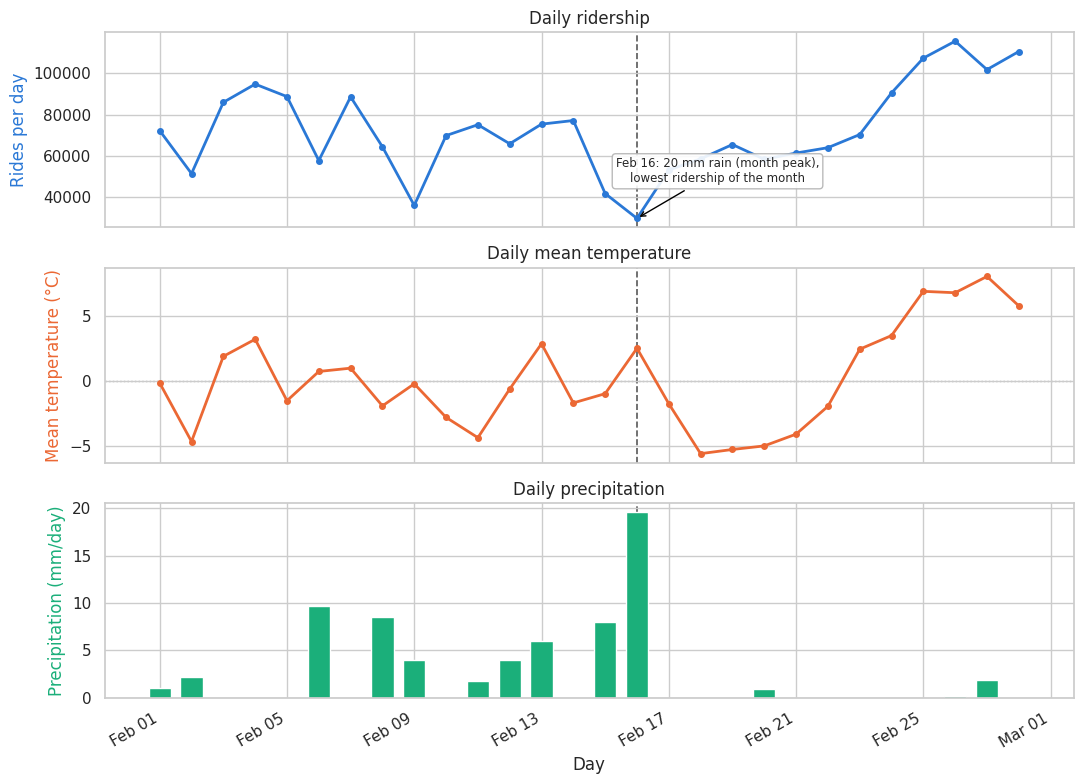

least-ridden day = Feb 16, wettest day = Feb 16 -> the same day
            rides  temperature  precipitation
hour_ts                                      
2025-02-16  29766          2.6           19.6
2025-02-23  70316          2.5            0.0


,Weather variable,Pearson correlation with daily rides,Observations
0,Mean temperature (°C),0.634774,28
1,Precipitation (mm/day),-0.553380,28


In [24]:
# Join hourly ride counts to the matching weather hour.
df["hour_ts"] = df["ended_at"].dt.floor("h")
rides_per_hour = df.groupby("hour_ts").size().reset_index(name="rides")
merged = rides_per_hour.merge(weather, left_on="hour_ts", right_on="datetime", how="inner")
print(f"{len(merged):,} hours joined "
      f"({merged['hour_ts'].min():%Y-%m-%d} -> {merged['hour_ts'].max():%Y-%m-%d})")

# Daily granularity
daily = merged.set_index("hour_ts").resample("D").agg(
    rides=("rides", "sum"),
    temperature=("temperature_2m", "mean"),
    precipitation=("precipitation", "sum"))

# Small multiples on a shared date axis
RIDES_C, TEMP_C, PRECIP_C = "#2a78d6", "#eb6834", "#1baf7a"
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(daily.index, daily["rides"], color=RIDES_C, lw=2, marker="o", ms=4)
axes[0].set_ylabel("Rides per day", color=RIDES_C)
axes[0].set_title("Daily ridership")

axes[1].plot(daily.index, daily["temperature"], color=TEMP_C, lw=2, marker="o", ms=4)
axes[1].set_ylabel("Mean temperature (°C)", color=TEMP_C)
axes[1].set_title("Daily mean temperature")
axes[1].axhline(0, color="0.6", lw=1, ls=":", zorder=0)

# Precipitation is a daily accumulation that is zero on most days
axes[2].bar(daily.index, daily["precipitation"], color=PRECIP_C, width=0.7)
axes[2].set_ylabel("Precipitation (mm/day)", color=PRECIP_C)
axes[2].set_title("Daily precipitation")

# The report claims the least-ridden day is also the wettest, so check it rather than assume it.
worst = daily["rides"].idxmin()
wettest = daily["precipitation"].idxmax()
for ax in axes:
    ax.axvline(worst, color="0.35", lw=1.2, ls="--", zorder=0)
axes[0].annotate(f"{worst:%b %d}: {daily.loc[worst, 'precipitation']:.0f} mm rain"
                 f"{' (month peak)' if worst == wettest else ''},\n"
                 f"lowest ridership of the month",
                 xy=(worst, daily.loc[worst, "rides"]), xytext=(58, 26),
                 textcoords="offset points", ha="center", fontsize=8.5,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9),
                 arrowprops=dict(arrowstyle="->", color="black", lw=1))

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[2].set_xlabel("Day")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"least-ridden day = {worst:%b %d}, wettest day = {wettest:%b %d} "
      f"-> {'the same day' if worst == wettest else 'different days'}")
# Same weekday, one wet and one dry, to separate rain from the weekend effect.
print(daily.loc[[worst, worst + pd.Timedelta(days=7)]].round(1))

correlation_table = pd.DataFrame({
    "Weather variable": ["Mean temperature (°C)", "Precipitation (mm/day)"],
    "Pearson correlation with daily rides": [
        daily["rides"].corr(daily["temperature"]),
        daily["rides"].corr(daily["precipitation"]),
    ],
    "Observations": [len(daily), len(daily)],
})
correlation_table

### 3.3 Data Quality

The feed is a well known and properly maintained source, so the checks here are limited to
completeness.

The table reports the missing count and percentage for every raw column.

In [25]:
raw_cols = ["datetime", "temperature_2m", "precipitation", "weather_code", "wind_speed_10m"]
# Nulls alone would not catch an absent row, so count local hours (honest across the DST changes).
expected_hours = len(pd.date_range(start_date, end_date + timedelta(days=1),
                                   freq="h", tz=NYC_TZ, inclusive="left"))
print(f"{len(weather):,} hourly rows loaded, {expected_hours:,} expected "
      f"({start_date} -> {end_date}); missing values per column:")
missing_table(weather, raw_cols)

8,760 hourly rows loaded, 8,760 expected (2025-01-01 -> 2025-12-31); missing values per column:


,missing,pct (%)
datetime,0,0.0
temperature_2m,0,0.0
precipitation,0,0.0
weather_code,0,0.0
wind_speed_10m,0,0.0


## 4. Bike Lanes

Follows the technical analysis of NYC's designated bike-route network, published annually by NYC DOT on
[NYC OpenData](https://data.cityofnewyork.us/dataset/New-York-City-Bike-Routes/mzxg-pwib/about_data)

In [26]:
routes = pd.read_csv(BIKE_ROUTES_URL, low_memory=False)

# instdate/ret_date arrive as MM/DD/YYYY text; parse once here, every section below reads these.
routes["install_date"] = pd.to_datetime(routes["instdate"], format="%m/%d/%Y", errors="coerce")
routes["retire_date"] = pd.to_datetime(routes["ret_date"], format="%m/%d/%Y", errors="coerce")

print(f"{len(routes):,} segments x {routes.shape[1]} columns")
print("Columns:", routes.columns.tolist())
routes.head()

29,695 segments x 27 columns
Columns: ['the_geom', 'segmentid', 'bikeid', 'prevbikeid', 'status', 'boro', 'street', 'fromstreet', 'tostreet', 'onoffst', 'facilitycl', 'allclasses', 'bikedir', 'lanecount', 'ft_facilit', 'tf_facilit', 'ft2facilit', 'tf2facilit', 'instdate', 'ret_date', 'grnwy', 'gwsystem', 'gwsys2', 'spur', 'gwyjuris', 'install_date', 'retire_date']


,the_geom,segmentid,bikeid,prevbikeid,status,boro,street,fromstreet,tostreet,onoffst,facilitycl,allclasses,bikedir,lanecount,ft_facilit,tf_facilit,ft2facilit,tf2facilit,instdate,ret_date,grnwy,gwsystem,gwsys2,spur,gwyjuris,install_date,retire_date
0,MULTILINESTRING ((-73.98255629299425 40.731350...,190857,4,NaN,Current,1,1 AV,E 1 ST,E 20 ST,ON,I,I,R,1,Protected,NaN,NaN,NaN,10/01/2010,NaN,NaN,NaN,NaN,NaN,NaN,2010-10-01,NaT
1,MULTILINESTRING ((-73.91048159778626 40.874016...,338221,3046,NaN,Current,1,BROADWAY BR,9 AV,W 225 ST,OFF,L,L,2,0,Link,Link,NaN,NaN,12/26/1960,NaN,NaN,NaN,NaN,NaN,NaN,1960-12-26,NaT
2,MULTILINESTRING ((-73.99612861145164 40.678161...,22375,7972,NaN,Current,3,SMITH ST,SCHERMERHORN ST,HAMILTON AV,ON,II,II,L,1,NaN,Conventional,NaN,NaN,06/01/2010,NaN,NaN,NaN,NaN,NaN,NaN,2010-06-01,NaT
3,MULTILINESTRING ((-73.92810290445244 40.787832...,245597,3025,NaN,Current,1,RFK BR,MN QN BOUNDARY,HELL GATE CR,OFF,L,L,2,0,Link,Link,NaN,NaN,07/11/1936,NaN,NaN,NaN,NaN,NaN,NaN,1936-07-11,NaT
4,MULTILINESTRING ((-73.96453128895577 40.796970...,9007769,211,NaN,Current,1,COLUMBUS AV,CATHEDRAL PKWY,W 96 ST,ON,I,I,L,1,NaN,Protected,NaN,NaN,09/25/2013,NaN,NaN,NaN,NaN,NaN,NaN,2013-09-25,NaT


### 4.1 Structure and Summary

Distributed as a single CSV file, the dataset provides a current snapshot of the bike network
alongside a historical record, with the NYC Department of Transportation updating the file on an
annual basis. Each record represents a single segment of a bike facility.

In [27]:
routes.info()

print("\nFacility class (the highest class present on the segment):")
print(pd.crosstab(routes["facilitycl"], routes["status"], margins=True, margins_name="All"))
print(f"\nDistinct values ever taken by facilitycl : {sorted(routes['facilitycl'].unique())}")
print(f"Date range (install / retire)            : "
      f"{routes['install_date'].min():%Y-%m-%d} -> {routes['install_date'].max():%Y-%m-%d} / "
      f"{routes['retire_date'].min():%Y-%m-%d} -> {routes['retire_date'].max():%Y-%m-%d}")

<class 'pandas.DataFrame'>
RangeIndex: 29695 entries, 0 to 29694
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   the_geom      29695 non-null  str           
 1   segmentid     29695 non-null  int64         
 2   bikeid        29695 non-null  int64         
 3   prevbikeid    5380 non-null   float64       
 4   status        29695 non-null  str           
 5   boro          29695 non-null  int64         
 6   street        29695 non-null  str           
 7   fromstreet    29691 non-null  str           
 8   tostreet      29691 non-null  str           
 9   onoffst       29695 non-null  str           
 10  facilitycl    29695 non-null  str           
 11  allclasses    29695 non-null  str           
 12  bikedir       29695 non-null  str           
 13  lanecount     29695 non-null  int64         
 14  ft_facilit    22393 non-null  str           
 15  tf_facilit    22104 non-null  str           
 1

### 4.2 Spatial Overview

The geometry is what this dataset contributes to the dashboard, so the first thing to look at is
the network itself. Segments are drawn in the dashboard's own facility-class palette, and only
the ones **in service** are kept, which is what the dashboard shows before the year slider is
touched. Its spatial distribution closely mirrors the high-demand trip areas of section 1.4.

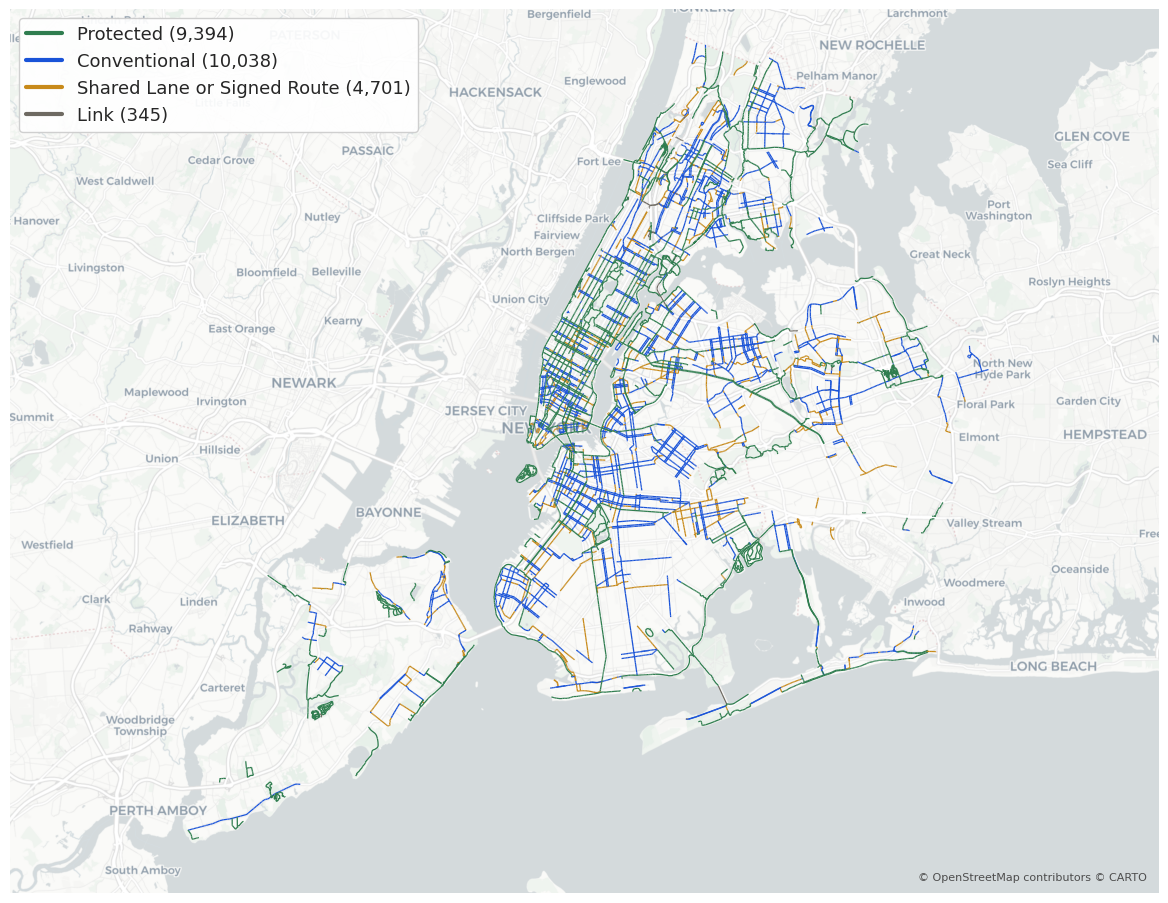

In [28]:
# Palette, wording and basemap copied from the dashboard (frontend .../utils/bikeRoutesLayer.js and mapConfig.js).
FACILITY_COLORS = {"I": "#2f7d4f", "II": "#1953d8", "III": "#c88a1a", "L": "#6e6a62"}
FACILITY_LABELS = {"I": "Protected", "II": "Conventional",
                   "III": "Shared Lane or Signed Route", "L": "Link"}
BASE_TILE_URL = "https://a.basemaps.cartocdn.com/light_all/{z}/{x}/{y}@2x.png"
# North-south is the city's full extent; east-west is widened to frame it in landscape.
NYC_BBOX = (-74.374, 40.47, -73.586, 40.93)   # lon_min, lat_min, lon_max, lat_max

WEB_MERCATOR_R = 6378137.0
WORLD = math.pi * WEB_MERCATOR_R

def to_mercator(lon, lat):
    """Lon/lat degrees -> Web Mercator metres, the projection the tiles are drawn in."""
    return (np.radians(lon) * WEB_MERCATOR_R,
            np.log(np.tan(np.pi / 4 + np.radians(lat) / 2)) * WEB_MERCATOR_R)

def fetch_basemap(bbox, zoom=11):
    """Stitch the Positron tiles covering bbox; returns the image and its Mercator extent."""
    lon_min, lat_min, lon_max, lat_max = bbox
    n = 2 ** zoom

    def tile_xy(lon, lat):
        lat_r = math.radians(lat)
        return (int((lon + 180) / 360 * n),
                int((1 - math.log(math.tan(lat_r) + 1 / math.cos(lat_r)) / math.pi) / 2 * n))

    x0, y0 = tile_xy(lon_min, lat_max)   # north-west tile
    x1, y1 = tile_xy(lon_max, lat_min)   # south-east tile

    tile_px, canvas = None, None
    for x in range(x0, x1 + 1):
        for y in range(y0, y1 + 1):
            img = Image.open(io.BytesIO(requests.get(
                BASE_TILE_URL.format(z=zoom, x=x, y=y), timeout=(5, 30)).content)).convert("RGB")
            if canvas is None:
                tile_px = img.size[0]
                canvas = Image.new("RGB", (tile_px * (x1 - x0 + 1), tile_px * (y1 - y0 + 1)))
            canvas.paste(img, ((x - x0) * tile_px, (y - y0) * tile_px))

    span = 2 * WORLD / n   # metres covered by one tile at this zoom
    return canvas, (-WORLD + x0 * span, -WORLD + (x1 + 1) * span,
                    WORLD - (y1 + 1) * span, WORLD - y0 * span)

_COORDS = re.compile(r"(-?\d+(?:\.\d+)?)\s+(-?\d+(?:\.\d+)?)")

def wkt_lines(wkt):
    """Each line of a (MULTI)LINESTRING as Mercator xy; WKT stores lon before lat."""
    lines = []
    for part in re.findall(r"\(([^()]+)\)", wkt):
        pts = np.array(_COORDS.findall(part), dtype=float)
        lines.append(np.column_stack(to_mercator(pts[:, 0], pts[:, 1])))
    return lines

current = routes[routes["retire_date"].isna()]
tiles, extent = fetch_basemap(NYC_BBOX)

fig, ax = plt.subplots(figsize=(12, 9.2))
ax.imshow(np.asarray(tiles), extent=extent, origin="upper", interpolation="bilinear")
# Least protected first, so the protected classes stay on top where facilities overlap.
for cls in ["L", "III", "II", "I"]:
    lines = [line for wkt in current.loc[current["facilitycl"] == cls, "the_geom"]
             for line in wkt_lines(wkt)]
    ax.add_collection(LineCollection(lines, colors=FACILITY_COLORS[cls], linewidths=0.9))

(x_min, x_max), (y_min, y_max) = to_mercator(np.array(NYC_BBOX[::2]), np.array(NYC_BBOX[1::2]))
ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max), aspect="equal")
ax.set_axis_off()
ax.legend(handles=[Line2D([], [], color=FACILITY_COLORS[c], lw=3,
                          label=f"{FACILITY_LABELS[c]} ({(current['facilitycl'] == c).sum():,})")
                   for c in FACILITY_COLORS],
          loc="upper left", fontsize=13, facecolor="white", framealpha=.92)
ax.annotate("\u00a9 OpenStreetMap contributors \u00a9 CARTO", xy=(0.99, 0.012),
            xycoords="axes fraction", ha="right", va="bottom", fontsize=8, color="0.3")
plt.tight_layout()
plt.show()

### 4.3 Temporal Overview

Because retired facilities stay in the file, the network can be replayed year by year. Counting
`instdate` above the axis and `ret_date` below it gives the dashboard's history chart: how much
was built and how much left service, every year.

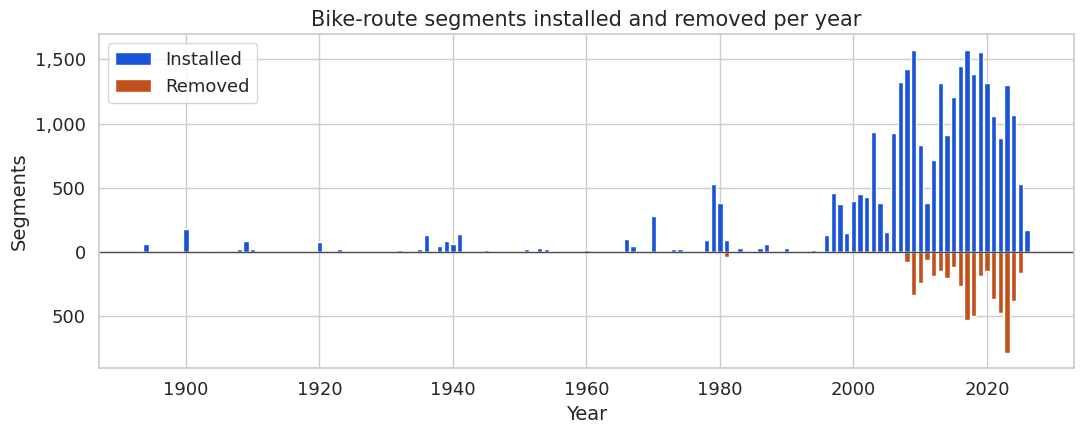

In [29]:
# Diverging bars, matching the dashboard's history chart (installed above, removed below).
INSTALLED_C, REMOVED_C = "#1953d8", "#c2501a"

install_year, retire_year = routes["install_date"].dt.year, routes["retire_date"].dt.year
years = np.arange(int(install_year.min()), int(install_year.max()) + 1)
installed = install_year.value_counts().reindex(years, fill_value=0)
removed = retire_year.value_counts().reindex(years, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(years, installed, color=INSTALLED_C, width=.8, label="Installed")
ax.bar(years, -removed, color=REMOVED_C, width=.8, label="Removed")
ax.axhline(0, color=".3", lw=1)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Segments", fontsize=14)
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(lambda v, _: f"{abs(int(v)):,}")
ax.legend(loc="upper left", fontsize=13)
ax.set_title("Bike-route segments installed and removed per year", fontsize=15)
plt.tight_layout()
plt.show()

### 4.4 Data Quality

Apart from the retirement date, which is empty by design for facilities still in service, every
column we consume is fully populated, every geometry parses, and none falls outside New York.
The problems are of a different kind: **dates that carry a sentinel**, and a **facility class that
reports only the best facility present on the segment**.

#### Missing Values

The table below is the evidence that nothing we consume is missing.

In [33]:
consumed = ["the_geom", "segmentid", "bikeid", "status", "boro", "street", "fromstreet",
            "tostreet", "facilitycl", "instdate", "ret_date"]
print(f"{len(routes):,} segments; per-column completeness "
      "(ret_date is null by design on records still in service):")
print(missing_table(routes, consumed).to_string())

raw_points = routes["the_geom"].map(lambda w: np.array(_COORDS.findall(w), dtype=float))
too_short = raw_points.map(len) < 2
outside = raw_points.map(lambda p: bool(
    p.ndim == 2 and ((p[:, 0] < NYC_LON_RANGE[0]) | (p[:, 0] > NYC_LON_RANGE[1])
                     | (p[:, 1] < NYC_LAT_RANGE[0]) | (p[:, 1] > NYC_LAT_RANGE[1])).any()))
print(f"Geometries with a point outside NYC       : {int(outside.sum())}")
print(f"Geometry types present                    : "
      f"{routes['the_geom'].str.split('(').str[0].str.strip().unique().tolist()}")

29,695 segments; per-column completeness (ret_date is null by design on records still in service):
            missing  pct (%)
ret_date      24478    82.43
fromstreet        4     0.01
tostreet          4     0.01
the_geom          0     0.00
segmentid         0     0.00
bikeid            0     0.00
status            0     0.00
boro              0     0.00
street            0     0.00
facilitycl        0     0.00
instdate          0     0.00
Geometries with a point outside NYC       : 0
Geometry types present                    : ['MULTILINESTRING', 'MULTILINESTRING EMPTY']


#### Sentinel Installation Dates

`instdate` is never null, which makes the file look complete on a missing-value check, but the
dictionary describes it as *"the **approximate** or exact date"* and unknown dates are encoded as
the sentinel **01/01/1900** rather than left blank.

In [31]:
SENTINEL = pd.Timestamp("1900-01-01")
sentinel = routes["install_date"] == SENTINEL
print(f"Segments dated 01/01/1900   : {sentinel.sum():,} "
      f"({sentinel.sum() / len(routes):.1%}), of which "
      f"{(sentinel & routes['retire_date'].isna()).sum():,} still in service")
print(f"Earliest real install date  : "
      f"{routes.loc[~sentinel, 'install_date'].min():%Y-%m-%d}")
print(f"Year-slider span it implies : {SENTINEL.year} -> {routes['install_date'].max().year} "
      f"({routes['install_date'].max().year - SENTINEL.year + 1} years, "
      f"{routes.loc[~sentinel, 'install_date'].dt.year.nunique()} of them non-empty)")

print("\nStreets carrying the sentinel, most segments first:")
print(routes.loc[sentinel, "street"].value_counts().head(5).to_string())

Segments dated 01/01/1900   : 177 (0.6%), of which 129 still in service
Earliest real install date  : 1894-06-15
Year-slider span it implies : 1900 -> 2026 (127 years, 69 of them non-empty)

Streets carrying the sentinel, most segments first:
street
VAN CORTLANDT PARK GREENWAY    44
EASTERN PKWY                   26
MOUNT LORETTO GREENWAY         14
73 AVE                         10
E 62 ST                        10


#### Facility Classification Bias

`facilitycl` reports the **highest** class present along a segment, while `allclasses` lists every
class on it. A street with a protected lane on one side and a shared lane on the other is therefore
classified entirely as protected, so a segment's class reads as the best available facility rather
than the conditions on both sides.

In [32]:
mixed = routes["allclasses"].str.contains(",")
print(f"Segments carrying more than one class : {int(mixed.sum()):,} ({mixed.mean():.1%})")

print("\nMost common combinations (all classes present -> class reported):")
print(routes.loc[mixed].groupby(["allclasses", "facilitycl"]).size()
      .sort_values(ascending=False).head(5).to_string())

Segments carrying more than one class : 830 (2.8%)

Most common combinations (all classes present -> class reported):
allclasses  facilitycl
III,II      II            286
II,III      II            266
II,I        I              61
I,III       I              49
III,I       I              45
